### LangChain 다음은 LangGraph 
#### LangGraph는 에이전트 워크플로우를 그래프로 모델링하는 프레임워크이다.

> **에지**를 따라서 흐름을 제어하며 **상태**를 통해 데이터를 공유하는 구조로<br> 
> 복잡한 AI 워크플로우를 직관적으로 설계할 수 있다.

지금까지 **LangChain**으로 ChatModel 호출, PromptTemplate, LCEL(`|` 체이닝),<br>
출력 파서, 대화 메모리(`RunnableWithMessageHistory`)까지 다뤘다. 이번 시간에는<br>
그 다음 단계인 **LangGraph**를 기초부터 다룬다.

핵심 질문은 하나다.

> **"LCEL 체인만으로는 왜 부족한가?"**

LCEL은 `prompt | llm | parser` 처럼 **한 방향으로 흐르는 파이프라인**을 만드는 데는
최적이지만, <br>다음과 같은 상황에서는 부자연스러워진다.

- 결과가 마음에 들 때까지 **같은 단계를 반복**해야 할 때 (사이클)
- 중간 결과에 따라 **완전히 다른 경로로 갈라져야** 할 때 (조건부 분기)
- 여러 턴에 걸친 **상태를 그래프 자체가 기억**해야 할 때 (체크포인터)
- 위험한 행동 전에 **사람이 직접 승인**해야 할 때 (human-in-the-loop)

LangGraph는 이 네 가지를 **네이티브로 지원하는 저수준 오케스트레이션 엔진**이다.<br>
LangChain 팀이 만들었으며 PyPI 공식 설명에 따르면 LangChain 1.x의 에이전트(create_agent)도<br>
내부적으로 LangGraph 를 사용해서 구축되었다 ("LangChain agents are built on top
of LangGraph").

- LangChain (LCEL): 데이터가 한 방향으로만 흐르는 직선형 구조(DAG, Directed Acyclic Graph)에 최적화되어 있다. <br>
  A가 끝나면 B, B가 끝나면 C로 가는 파이프라인이다.

- LangGraph: 에이전트가 스스로 판단하여 뒤로 돌아가거나(반복), 길을 바꾸고, 상태를 유지하는 <br>
  순환형 구조(Cyclic Graph)를 제어하기 위한 프레임워크이다.

### 다루는 내용 (순서대로)

1. 환경 설정 및 버전 확인
2. LangChain vs LangGraph — 왜 필요한가 (LCEL의 한계 직접 체험)
3. LangGraph 핵심 개념: `State` · `Node` · `Edge` · `START`/`END`
4. 여러 노드 연결하기 (선형 파이프라인)
5. 조건부 분기 (`add_conditional_edges`)
6. 사이클(반복) — LangGraph의 핵심 차별점
7. 체크포인터 — 여러 턴에 걸친 상태 기억 (`MemorySaver`, `thread_id`)
8. Human-in-the-loop (`interrupt`, `Command(resume=...)`)
9. 스트리밍 (`stream_mode`)
10. 기존 LangChain 자산(LCEL 체인) 그래프 노드로 재사용하기
11. LangChain vs LangGraph 정리 & 다음 단계

### 사전 준비물

- 이전 시간에 만든 `eduvenv` 가상환경 (Python 3.11+)
- OpenAI API 키 (`OPENAI_API_KEY` 환경변수)
- 로컬 Ollama + `exaone3.5` 모델 (`ollama pull exaone3.5`) — 선택 사항
- 그래프 구조/분기/사이클 검증 셀은 `FakeMessagesListChatModel`을 사용하므로<br>
  **API 키가 없어도 먼저 실행하며 구조를 확인**할 수 있다.

### 1. 환경 설정 및 버전 확인

아래 명령으로 필요한 패키지를 설치한다 (2026-07-11 기준 최신 안정 버전).

```bash
pip install langgraph
```

> 💡 **버전 참고**: `langchain`은 2025년 하반기에 1.0을 기점으로 에이전트 관련 API가
> 크게 정리되었다 (`create_tool_calling_agent` + `AgentExecutor` 조합 대신
> `langchain.agents.create_agent`가 표준 진입점이 되었고, 내부적으로 LangGraph를
> 사용한다). 이전 시간 자료에 `AgentExecutor`가 등장했다면 그것은 0.x 시절 방식이며,
> LangGraph를 배우고 나면 왜 `create_agent`가 LangGraph 위에서 동작하는지 이해할 수 있다.

In [1]:
from importlib.metadata import version

for pkg in ["langchain", "langgraph", "langchain-openai", "langchain-ollama"]:
    print(f"{pkg:20s}: {version(pkg)}")

assert version("langgraph").startswith("1."), "LangGraph 1.x 버전을 권장합니다"
print("\n✅ 환경 점검 완료")

langchain           : 1.3.11
langgraph           : 1.2.8
langchain-openai    : 1.3.3
langchain-ollama    : 1.1.0

✅ 환경 점검 완료


assert [조건], [조건이 거짓일 때 출력할 에러 메시지] : 조건이 거짓일 때 메시지로 초기화된 AssertionError가 발생됨

### 2. LangChain vs LangGraph — 왜 필요한가

| 구분 | LangChain (LCEL) | LangGraph |
|---|---|---|
| 비유 | LLM 앱을 만드는 **재료 상자** | 그 재료를 조립하는 **오케스트레이션 엔진** |
| 실행 모양 | `prompt \| llm \| parser` — **단방향 파이프라인** | `State` 중심 — **노드와 커맨드로 제어하는 상태 머신** |
| 반복(사이클) | 구조적으로 불가능 (직접 `while`로 감싸야 함) | 라우팅 조건이나 `command=goto=...`로 자연스러운 루프 구현 |
| 조건부 분기 | `RunnableBranch` (매우 제한적이고 복잡함) | 노드 내부에서 **Command(goto="노드명")** 으로 자유롭게 분기 |
| 상태 유지 | `RunnableWithMessageHistory` (대화 대화 이력) | `Checkpointer` — 변수, 메모리 등 그래프의 모든 State 완벽 저장 |
| 중단 후 재개 | 지원 안 함(처음부터 다시 실행) | **interrupt()** 로 일시정지후 **Command(resume=...)** 로 이어서 실행 |
| 관계 | 독립적 사용 가능 | LangChain 없이 pure python 객체로도 구동 가능하며 LangChain의 에이전트는 사실상 LangGraph로 대체됨 |

#### 직접 체험: LCEL로 "재시도(retry) 로직"을 짜보면?

다음은 "생성된 답변이 너무 짧으면 다시 생성한다"는 아주 단순한 반복 로직을 **LCEL 체인만으로** 구현한 것이다.<br> 
체인 자체는 여전히 한 방향이라, 반복은 파이썬 `while` 루프가 바깥에서 체인을 감싸는 방식으로만 가능하다.

In [2]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.language_models.fake_chat_models import FakeListChatModel

# 짧은 답변 -> 긴 답변 순으로 응답하는 가짜 LLM (API 키 없이 구조 검증용)
fake_llm = FakeListChatModel(responses=["짧음", "짧음", "이번엔 충분히 긴 답변입니다 " * 5])

prompt = ChatPromptTemplate.from_messages([
    ("system", "질문에 답하세요."),
    ("human", "{question}"),
])
chain = prompt | fake_llm | StrOutputParser()

# LCEL 체인 바깥에서 파이썬 while 루프로 "재시도"를 흉내내야 한다
MIN_LEN = 20
attempt = 0
result = ""
while attempt < 5:
    result = chain.invoke({"question": "LangGraph가 뭔가요?"})
    attempt += 1
    print(f"[시도 {attempt}] 길이={len(result)} -> {result[:20]}...")
    if len(result) >= MIN_LEN:
        break

assert len(result) >= MIN_LEN
print(f"\n✅ {attempt}번째 시도에서 통과 (LCEL 체인 자체는 반복을 모른다 — 바깥 while이 다 함)")

[시도 1] 길이=2 -> 짧음...
[시도 2] 길이=2 -> 짧음...
[시도 3] 길이=80 -> 이번엔 충분히 긴 답변입니다 이번엔 ...

✅ 3번째 시도에서 통과 (LCEL 체인 자체는 반복을 모른다 — 바깥 while이 다 함)


- LangChain의 한계<br>
체인 자체는 '재시도'라는 개념을 알지 못한다. 그래서 반복 로직, 종료 조건, 시도 횟수 제한 같은 <br>
제어 흐름을 모두 체인 바깥의 일반 파이썬 코드로 구현해야 한다. 이 방식은 노드가 늘어나고 분기가 <br>
복잡해질수록 바깥 코드가 급격하게 복잡하고 지저분해진다는 단점이 있다.

- LangGraph의 해결책<br>
LangGraph는 이러한 반복, 분기, 상태 관리를 외부 코드가 아닌 그래프 구조(정의) 자체에 내재화하여 <br>
깔끔하게 해결해 준다.

### 3. LangGraph 핵심 개념: State · Node · Edge

LangGraph의 그래프는 네 가지 요소로 구성된다.

| 요소 | 의미 |
|---|---|
| **State** | 그래프 전체가 공유하는 중앙 저장소. 보통 `TypedDict`로 정의하며 값이 누적될지 덮어써질지 결정하는 **리듀서(Reducer)** 기능을 지정할 수 있음 |
| **Node** | 현재 State를 입력받아 비즈니스 로직(LLM 호출, 툴 호출)을 수행하고 갱신 상태값이나 다음 행동을 지시하는 Command 객체를 반환하는 함수 |
| **Edge** | 노드와 노드를 익는 정적 경로. 노드가 반환하는 Command(goto=...)를 통해 Edge 없이도 동적으로 다음 노드를 찾아갈 수 있음 |
| **START / END** | 그래프의 진입점과 탈출점을 지정하는 특수 제어 노드 |

가장 단순한 그래프: **노드 하나**, 시작에서 끝까지 한 번만 실행 : [START] -> (단 하나의 작업 노드) -> [END]

In [4]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# [1] 상태(State) 정의: 노드끼리 주고받을 데이터 주머니
class TestState(TypedDict):
    text: str

# [2] 노드(Node) 정의: 데이터를 받아서 수정하고 리턴하는 순수 파이썬 함수
def step_one(state: TestState):
    print("-> 1번 노드 실행 중")
    return {"text": state["text"] + " [1단계 통과]"}

def step_two(state: TestState):
    print("-> 2번 노드 실행 중")
    return {"text": state["text"] + " [2단계 통과]"}

# [3] 그래프 빌더 초기화
builder = StateGraph(TestState)

# [4] 노드 추가 (이름, 함수)
builder.add_node("node_1", step_one)
builder.add_node("node_2", step_two)

# [5] 엣지(선) 연결: 흐름 정의
# START에서 node_1로 가고, node_1이 끝나면 node_2로 가고, node_2가 끝나면 종료(END)한다.
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# [6] 컴파일: 실행 가능한 애플리렉션으로 변환
graph = builder.compile()

# [7] 테스트 실행
initial_state = {"text": "시작 데이터"}
print("=== 그래프 실행 시작 ===")
final_output = graph.invoke(initial_state)
print("=== 그래프 실행 완료 ===\n")

print("최종 결과물:")
print(final_output)

=== 그래프 실행 시작 ===
-> 1번 노드 실행 중
-> 2번 노드 실행 중
=== 그래프 실행 완료 ===

최종 결과물:
{'text': '시작 데이터 [1단계 통과] [2단계 통과]'}


In [5]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class SimpleState(TypedDict):
    question: str
    answer: str

def answer_node(state: SimpleState) -> dict:
    """질문을 받아 답을 채우는 노드. 지금은 가짜 로직으로 구조만 확인한다."""
    return {"answer": f"'{state['question']}'에 대한 답변입니다."}

builder = StateGraph(SimpleState)
builder.add_node("answer", answer_node)

builder.add_edge(START, "answer")
builder.add_edge("answer", END)

graph = builder.compile()

result = graph.invoke({"question": "LangGraph 기초가 뭔가요?", "answer": ""})
print(result)

assert result["answer"].startswith("'LangGraph 기초가 뭔가요?'")
print("\n✅ 최소 그래프(노드 1개) 실행 확인")

{'question': 'LangGraph 기초가 뭔가요?', 'answer': "'LangGraph 기초가 뭔가요?'에 대한 답변입니다."}

✅ 최소 그래프(노드 1개) 실행 확인


### 실제 LLM을 노드로 사용하기 (gpt-4o-mini)

위 `answer_node`를 실제 `ChatOpenAI` 호출로 바꾸면 그대로 실전 그래프가 된다.\
노드 함수의 시그니처는 동일하다 — **State를 받아서 State의 일부를 딕셔너리로
반환**한다.

In [6]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)


def llm_answer_node(state: SimpleState) -> dict:
    response = llm.invoke(state["question"])
    return {"answer": response.content}


builder2 = StateGraph(SimpleState)
builder2.add_node("answer", llm_answer_node)

builder2.add_edge(START, "answer")
builder2.add_edge("answer", END)

llm_graph = builder2.compile()

In [8]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="exaone3.5", temperature=0)


def llm_answer_node(state: SimpleState) -> dict:
    response = llm.invoke(state["question"])
    return {"answer": response.content}


builder2 = StateGraph(SimpleState)
builder2.add_node("answer", llm_answer_node)

builder2.add_edge(START, "answer")
builder2.add_edge("answer", END)

llm_graph = builder2.compile()

In [9]:
result = llm_graph.invoke({"question": "LangGraph를 한 문장으로 설명해줘", "answer": ""})
print(result["answer"])

LangGraph는 언어 모델과 그래프 신경망을 결합하여 텍스트와 그래프 데이터 간의 복잡한 관계를 효과적으로 학습하고 이해하는 모델입니다.


### 4. 여러 노드 연결하기 (선형 파이프라인)

노드 여러 개를 `add_edge`를 사용해서 순서대로 이으면 파이프라인이 된다. \
아래는 **"질문 분류 -> 답변 생성 -> 답변 검증"** 3단계 파이프라인이다. \
LCEL로도 충분히 만들 수 있는 수준이지만, 각 단계가 **독립된 노드**로 분리되어 있어서\
나중에 분기·재시도를 끼워 넣기 쉽다는 점이 다르다.

In [11]:
class PipelineState(TypedDict):
    question: str
    category: str
    answer: str
    is_valid: bool


def classify_node(state: PipelineState) -> dict:
    q = state["question"]
    category = "기술" if any(k in q for k in ["코드", "에러", "설치"]) else "일반"
    return {"category": category}


def generate_node(state: PipelineState) -> dict:
    return {"answer": f"[{state['category']} 답변] {state['question']}에 대한 답변입니다."}


def validate_node(state: PipelineState) -> dict:
    return {"is_valid": len(state["answer"]) > 5}


builder3 = StateGraph(PipelineState)
builder3.add_node("classify", classify_node)
builder3.add_node("generate", generate_node)
builder3.add_node("validate", validate_node)

builder3.add_edge(START, "classify")
builder3.add_edge("classify", "generate")
builder3.add_edge("generate", "validate")
builder3.add_edge("validate", END)

pipeline = builder3.compile()

result = pipeline.invoke({"question": "설치 에러가 발생해요", "category": "", "answer": "", "is_valid": False})
print(result)

assert result["category"] == "기술"
assert result["is_valid"] is True
print("\n✅ 3단계 선형 파이프라인 확인 (classify -> generate -> validate)")

{'question': '설치 에러가 발생해요', 'category': '기술', 'answer': '[기술 답변] 설치 에러가 발생해요에 대한 답변입니다.', 'is_valid': True}

✅ 3단계 선형 파이프라인 확인 (classify -> generate -> validate)


- 모든 노드는 중간 저장소인 State와만 소통한다.

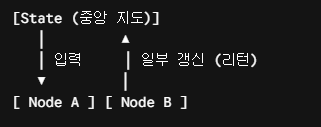

### 5. 조건부 분기 (`add_conditional_edges`)

add_edge: 항상 정해진 하나의 노드로만 이동 (고정 경로)\
add_conditional_edges: 상태(State)에 따라 다른 노드로 분기 (동적 경로)

- 핵심 구현: 현재 상태를 매개변수로 받는 '라우팅 함수'를 구현

- 동작 원리: 라우팅 함수가 조건문(if/else)을 거쳐 "다음에 실행할 노드 이름"을 문자열로 리턴

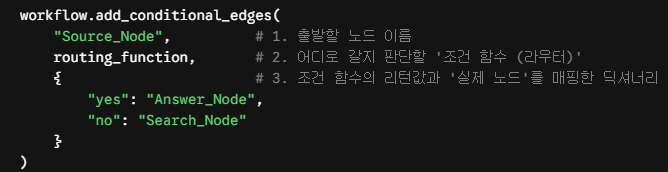

In [10]:
class RouteState(TypedDict):
    question: str
    category: str
    answer: str

def classify_node2(state: RouteState) -> dict:
    q = state["question"]
    category = "기술" if any(k in q for k in ["코드", "에러", "설치"]) else "일반"
    return {"category": category}


def tech_answer_node(state: RouteState) -> dict:
    return {"answer": f"[기술 전용 답변] @{state['question']}@"}


def general_answer_node(state: RouteState) -> dict:
    return {"answer": f"[일반 답변] #{state['question']}#"}


def route_by_category(state: RouteState) -> str:
    """라우팅 함수: 다음에 실행할 노드 '이름'을 문자열로 반환한다."""
    return "tech" if state["category"] == "기술" else "general"


builder4 = StateGraph(RouteState)
builder4.add_node("classify", classify_node2)
builder4.add_node("tech", tech_answer_node)
builder4.add_node("general", general_answer_node)

builder4.add_edge(START, "classify")
builder4.add_conditional_edges(
    "classify",
    route_by_category,
    {"tech": "tech", "general": "general"},  # 반환값 -> 실제 노드 이름 매핑
)
builder4.add_edge("tech", END)
builder4.add_edge("general", END)

router_graph = builder4.compile()

r1 = router_graph.invoke({"question": "파이썬 설치 에러 해결법", "category": "", "answer": ""})
r2 = router_graph.invoke({"question": "오늘 날씨 어때요", "category": "", "answer": ""})
print(r1["answer"])
print(r2["answer"])

assert r1["answer"].startswith("[기술 전용")
assert r2["answer"].startswith("[일반")
print("\n✅ 조건부 분기 확인 (기술/일반 경로가 다르게 실행됨)")

[기술 전용 답변] @파이썬 설치 에러 해결법@
[일반 답변] #오늘 날씨 어때요#

✅ 조건부 분기 확인 (기술/일반 경로가 다르게 실행됨)


In [ ]:
from IPython.display import Image, display

#  반드시 컴파일(compile)된 그래프 객체를 사용해야 합니다.
router_graph = builder4.compile()

try:
    # 그래프를 PNG 이미지 바이너리로 가져와서 화면에 출력합니다.
    display(Image(router_graph.get_graph().draw_mermaid_png()))
except Exception:
    # 이 옵션은 추가적인 의존성 라이브러리가 필요할 수 있어서 예외 처리를 해두면 안전합니다.
    print("그래프 이미지를 렌더링할 수 없습니다. 관련 라이브러리를 확인해주세요.")

#### add_conditional_edges 방식에서 Command 방식으로 확장됨

- 기존 : [작업 완료] ──> [상태 업데이트] ──> [외부 라우팅 함수 호출] ──> [딕셔너리 매핑 확인] ──> [다음 노드]

- 최신 : [작업 완료] ──> [Command 객체 리턴 (상태 갱신 + 다음 목적지 명시)] ──> [다음 노드]

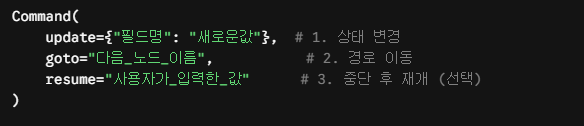

상태를 update 값으로 변경하고 goto 에 지정된 노드로 가라

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command  # 👈 최신 패러다임의 핵심 객체 임포트

class RouteState(TypedDict):
    question: str
    category: str
    answer: str

# 1. 분류 노드 내부에서 직접 상태 업데이트와 이동(goto)을 한 번에 처리합니다.
def classify_node2(state: RouteState) -> Command: # 👈 리턴 타입이 Command로 변경됨
    q = state["question"]
    category = "기술" if any(k in q for k in ["코드", "에러", "설치"]) else "일반"
    
    # 다음 목적지를 결정합니다.
    next_node = "tech" if category == "기술" else "general"
    
    # Command 객체를 통해 상태(update)와 이동경로(goto)를 함께 반환합니다.
    return Command(
        update={"category": category}, 
        goto=next_node
    )


def tech_answer_node(state: RouteState) -> dict:
    return {"answer": f"[기술 전용 답변] @{state['question']}@"}


def general_answer_node(state: RouteState) -> dict:
    return {"answer": f"[일반 답변] #{state['question']}#"}


builder4new = StateGraph(RouteState)
builder4new.add_node("classify", classify_node2)
builder4new.add_node("tech", tech_answer_node)
builder4new.add_node("general", general_answer_node)

# ─── 🛠️ 그래프 연결부 구조 조정 ───
builder4new.add_edge(START, "classify")

# ❌ builder4.add_conditional_edges(...) 전체 삭제됨!
# ❌ 별도의 라우팅 함수(route_by_category) 전체 삭제됨!

builder4new.add_edge("tech", END)
builder4new.add_edge("general", END)

router_graph = builder4new.compile()

# ─── 🏃‍♂️ 실행 및 검증 (기존과 완전히 동일) ───
r1 = router_graph.invoke({"question": "파이썬 설치 에러 해결법", "category": "", "answer": ""})
r2 = router_graph.invoke({"question": "오늘 날씨 어때요", "category": "", "answer": ""})
print(r1["answer"])
print(r2["answer"])

assert r1["answer"].startswith("[기술 전용")
assert r2["answer"].startswith("[일반")
print("\n✅ 최신 Command 기반 조건부 분기 확인 완료!")

### 6. 사이클(반복) — LangGraph의 핵심 차별점

LangChain 만을 사용할 때 LCEL로 재시도를 만들려면 **바깥 파이썬 while문**이 필요했다.\
LangGraph에서는 그냥 **엣지로 이전 노드를 다시 가리키면** 사이클이 된다.

아래는 "답변 생성 -> 품질 체크 -> 부족하면 다시 생성"을 그래프 자체의 사이클로 구현한 예이다.<br>
무한 루프 방지를 위해 상태에 `retry_count`를 두고, 라우팅 함수에서 최대 횟수를 넘으면 `END`로 보낸다.

In [ ]:
from langchain_core.language_models.fake_chat_models import FakeListChatModel

# 처음 두 번은 짧게, 세 번째는 충분히 길게 응답하는 가짜 LLM
critique_llm = FakeListChatModel(responses=["짧다", "여전히 짧다", "이번엔 충분히 상세하고 긴 답변입니다" * 4]) #3개 뭐가 3개인가? 

class RetryState(TypedDict):
    question: str
    answer: str
    retry_count: int

MAX_RETRY = 3

def generate_answer_node(state: RetryState) -> dict:
    response = critique_llm.invoke(state["question"])
    return {"answer": response.content, "retry_count": state["retry_count"] + 1}


def quality_gate(state: RetryState) -> str:
    """품질이 부족하고 재시도 횟수가 남았으면 'retry', 아니면 'done'."""
    if len(state["answer"]) >= 20 or state["retry_count"] >= MAX_RETRY:
        return "done"
    return "retry"


builder5 = StateGraph(RetryState)
builder5.add_node("generate", generate_answer_node)

builder5.add_edge(START, "generate")
builder5.add_conditional_edges(
    "generate", #generate로 등록된 노드면 계속 반복함. 
    quality_gate,
    {"retry": "generate", "done": END},  # 'retry'면 자기 자신(generate)으로 되돌아감 = 사이클
)

retry_graph = builder5.compile()

result = retry_graph.invoke({"question": "LangGraph 사이클 예제", "answer": "", "retry_count": 0})
print(result)

assert len(result["answer"]) >= 20
assert result["retry_count"] <= MAX_RETRY
print(f"\n✅ {result['retry_count']}번 만에 통과 — 그래프 정의 자체에 반복이 내장됨 (바깥 while 불필요)")

{'question': 'LangGraph 사이클 예제', 'answer': '이번엔 충분히 상세하고 긴 답변입니다 이번엔 충분히 상세하고 긴 답변입니다 이번엔 충분히 상세하고 긴 답변입니다 이번엔 충분히 상세하고 긴 답변입니다 ', 'retry_count': 3}

✅ 3번 만에 통과 — 그래프 정의 자체에 반복이 내장됨 (바깥 while 불필요)


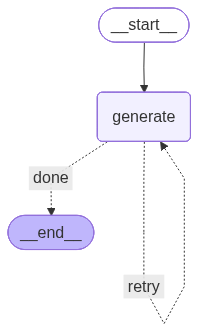

In [13]:
from IPython.display import Image, display

#  반드시 컴파일(compile)된 그래프 객체를 사용해야 합니다.
router_graph = builder5.compile()

try:
    # 그래프를 PNG 이미지 바이너리로 가져와서 화면에 출력합니다.
    display(Image(router_graph.get_graph().draw_mermaid_png()))
except Exception:
    # 이 옵션은 추가적인 의존성 라이브러리가 필요할 수 있어서 예외 처리를 해두면 안전합니다.
    print("그래프 이미지를 렌더링할 수 없습니다. 관련 라이브러리를 확인해주세요.")

> ⚠️ **무한 루프 주의**: 사이클을 만들 때는 반드시 종료 조건(위 예제의
> `retry_count >= MAX_RETRY`)을 넣어야 한다. <br>라우팅 함수가 항상 `"retry"`만
> 반환하면 그래프가 종료되지 않는다. <br>LangGraph는 기본적으로
> `recursion_limit`(기본 25:노드가 실행된 횟수)을 넘기면 <br>`GraphRecursionError`를 던져 안전장치
> 역할을 하지만, 의도한 로직으로 종료 조건을 두는 것이 정석이다.

In [14]:
from typing import TypedDict
from langchain_core.language_models.fake_chat_models import FakeListChatModel
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command  # 👈 최신 패러다임 핵심 객체 임포트

# 처음 두 번은 짧게, 세 번째는 충분히 길게 응답하는 가짜 LLM
critique_llm = FakeListChatModel(responses=["짧다", "여전히 짧다", "이번엔 충분히 상세하고 긴 답변입니다 " * 4])

class RetryState(TypedDict):
    question: str
    answer: str
    retry_count: int

MAX_RETRY = 3

# 1. 노드 내부에서 생성, 카운트 증가, 품질 게이트 검증까지 한 번에 처리합니다.
def generate_answer_node(state: RetryState) -> Command: # 👈 리턴 타입이 Command로 변경됨
    # LLM 답변 생성
    response = critique_llm.invoke(state["question"])
    next_retry_count = state["retry_count"] + 1
    current_answer = response.content
    
    # ─── 🛠️ 품질 게이트(기존 quality_gate 역할) 내재화 ───
    # 글자 수가 20자 이상이거나, 최대 재시도 횟수에 도달했다면 끝냅니다.
    if len(current_answer) >= 20 or next_retry_count >= MAX_RETRY:
        next_destination = END
    else:
        # 조건에 만족하지 못하면 자기 자신("generate") 노드로 되돌아갑니다. (사이클)
        next_destination = "generate"
        
    # 상태 업데이트 값과 다음 목적지를 Command로 반환합니다.
    return Command(
        update={
            "answer": current_answer, 
            "retry_count": next_retry_count
        },
        goto=next_destination
    )


builder5n = StateGraph(RetryState)
# 노드는 하나만 등록하면 됩니다.
builder5n.add_node("generate", generate_answer_node)

# ─── 🛠️ 그래프 연결부 구조 조정 ───
builder5n.add_edge(START, "generate")

# ❌ builder5.add_conditional_edges(...) 전체 삭제!
# ❌ 외부 quality_gate(state) 함수 전체 삭제!

retry_graph = builder5n.compile()

# ─── 🏃‍♂️ 실행 및 검증 (기존과 완전히 동일) ───
result = retry_graph.invoke({"question": "LangGraph 사이클 예제", "answer": "", "retry_count": 0})
print(result)

assert len(result["answer"]) >= 20
assert result["retry_count"] <= MAX_RETRY
print(f"\n✅ {result['retry_count']}번 만에 통과 — 최신 Command 기반으로 반복 루프 완벽 작동!")

{'question': 'LangGraph 사이클 예제', 'answer': '이번엔 충분히 상세하고 긴 답변입니다 이번엔 충분히 상세하고 긴 답변입니다 이번엔 충분히 상세하고 긴 답변입니다 이번엔 충분히 상세하고 긴 답변입니다 ', 'retry_count': 3}

✅ 3번 만에 통과 — 최신 Command 기반으로 반복 루프 완벽 작동!


### 7. 체크포인터 — 여러 턴에 걸친 상태 기억

- invoke() 는 1회성 실행 단발성 요청/응답의 특성을 갖는다.
- 대화형 메모리 구현 : 그래프에 체크포인터(Checkpointer)를 결합 및 상태 저장 및 유지
- 식별 방법 : 실행 시 설정 값(config)에 thread_id를 포함하여 "어떤 사용자의 어떤 대화 세션인지"를 명확하게 구분함.

- `langgraph.checkpoint.memory.MemorySaver` — 프로세스 메모리에 저장 (개발/실습용)
- 운영 환경에서는 `langgraph-checkpoint-postgres`, `langgraph-checkpoint-sqlite` 등의 영속 저장소를 주로 사용한다. 

> config = {"configurable": {"thread_id": "xxxxxx"}}\
> graph.invoke(initial_state, config)

In [15]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from typing import Annotated
from langchain_core.messages import HumanMessage

class ChatState(TypedDict):
    messages: Annotated[list, add_messages]  # 메시지가 자동으로 누적(append)됨

chat_llm = FakeListChatModel(responses=["안녕하세요! 반갑습니다.", "네, 아까 인사 나눴었죠!"])
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

def chat_node(state: ChatState) -> dict:
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

builder6 = StateGraph(ChatState)
builder6.add_node("chat", chat_node)
builder6.add_edge(START, "chat")
builder6.add_edge("chat", END)

chat_graph = builder6.compile(checkpointer=MemorySaver())

config = {"configurable": {"thread_id": "student-session-1"}}

turn1 = chat_graph.invoke({"messages": [HumanMessage("안녕? 내 이름은 유니코야.")]}, config=config)
turn2 = chat_graph.invoke({"messages": [HumanMessage("내 이름 기억하니?")]}, config=config)

print("turn1 메시지 수:", len(turn1["messages"]))
print("turn2 메시지 수:", len(turn2["messages"]))
for m in turn2["messages"]:
    print("-", type(m).__name__, ":", m.content)

# thread_id가 같으므로 turn2에는 turn1의 대화가 그대로 누적되어 있어야 한다
assert len(turn2["messages"]) == 4  # human1, ai1, human2, ai2
print("\n✅ 체크포인터로 두 번의 invoke 사이에 상태(대화 이력)가 이어짐 확인")

turn1 메시지 수: 2
turn2 메시지 수: 4
- HumanMessage : 안녕? 내 이름은 유니코야.
- AIMessage : 안녕하세요, 유니코! 만나서 반가워요. 어떻게 도와드릴까요?
- HumanMessage : 내 이름 기억하니?
- AIMessage : 네, 유니코님! 당신의 이름을 기억하고 있어요. 다른 질문이나 이야기하고 싶은 것이 있나요?

✅ 체크포인터로 두 번의 invoke 사이에 상태(대화 이력)가 이어짐 확인


`thread_id`만 바꾸면 완전히 독립된 새 대화가 시작된다. \
실제 서비스에서는 사용자별로 `thread_id`를 발급해서 관리하면 된다 (LangChain의 세션 ID 개념과 동일).

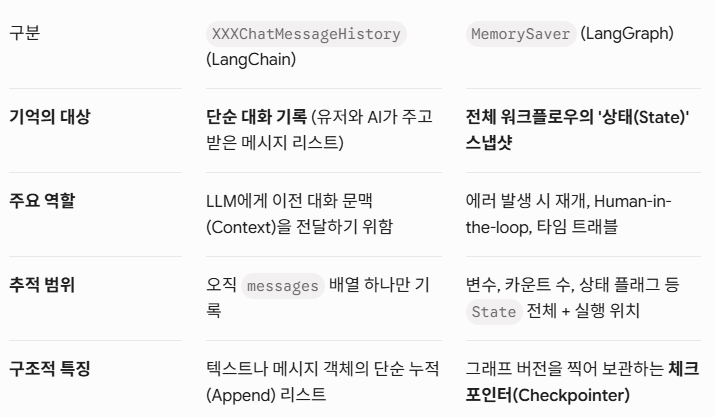

- XXXChatMessageHistory - 대화 전용 기록
- MemorySaver - 시스템 상태 체크포인터 

### 8. Human-in-the-loop (`interrupt`, `Command(resume=...)`)

삭제·이체처럼 되돌리기 어려운 행동 전에는 **사람의 승인**을 받고 싶을 때가 있다. \
LangGraph는 `interrupt()`를 호출하면 그래프 실행을 그 자리에서 **일시 정지**하고 값을 반환한다. \
사람이 확인 후 `Command(resume=...)`으로 같은 지점부터 재개한다. \
이 기능은 **체크포인터가 있어야** 동작한다 (정지된 상태를 어딘가에 저장해둬야 재개할 수 있으므로).

In [18]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

# 1. 상태 정의 (불필요한 데이터 제외하고 깔끔하게)
class HitlState(TypedDict):
    action: str
    result: str

# 2. 노드 정의
def request_approval_node(state: HitlState):
    # 여기서 그래프가 완전히 일시정지(suspend)됩니다.
    # 호출부(클라이언트)로 질문을 던지고, 사용자의 입력(resume)을 기다립니다.
    user_response = interrupt({"question": f"⚠️ [{state['action']}] 작업을 승인하시겠습니까? (y/n): "})
    
    # 사용자가 입력한 값(y 또는 n)을 상태에 결과로 임시 저장하거나 검증합니다.
    return {"result": user_response}

def execute_node(state: HitlState):
    # 사람이 입력한 값(result)에 따라 분기 처리
    if state["result"].lower() == 'y':
        return {"result": f"🚀 '{state['action']}' 작업을 성공적으로 실행했습니다."}
    else:
        return {"result": f"❌ '{state['action']}' 작업이 사용자에 의해 거부되었습니다."}

# 3. 그래프 빌드 및 컴파일 (HITL에는 체크포인터가 필수입니다)
builder = StateGraph(HitlState)
builder.add_node("request_approval", request_approval_node)
builder.add_node("execute", execute_node)

builder.add_edge(START, "request_approval")
builder.add_edge("request_approval", "execute")
builder.add_edge("execute", END)

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# ==========================================
# 실제 사람이 개입하는 인터랙티브 테스트 루프
# ==========================================
config = {"configurable": {"thread_id": "real-human-test"}}
initial_state = {"action": "고객 데이터베이스 영구 삭제"}

print("=== 1단계: 그래프 최초 실행 (사람의 승인 대기 단계) ===")
response = graph.invoke(initial_state, config)

# interrupt()를 만나면 리턴값 객체 내부에 '_interrupt' 키워드가 들어있습니다.
if "__interrupt__" in response:
    # 멈춘 시점에서 랭그래프가 보낸 인터럽트 정보(질문)를 추출합니다.
    interrupt_info = response["__interrupt__"][0].value
    
    # 💻 [실제 사람의 개입] 터미널에서 진짜 입력을 받습니다!
    human_input = input(interrupt_info["question"])
    
    print("\n=== 2단계: 사람의 입력을 그래프로 전달하여 재개(Resume) ===")
    # Command(resume=...)를 통해 멈췄던 노드의 interrupt() 위치로 값을 찔러 넣습니다.
    final_output = graph.invoke(Command(resume=human_input), config)
    
    print("최종 실행 결과:")
    print(final_output["result"])

=== 1단계: 그래프 최초 실행 (사람의 승인 대기 단계) ===

=== 2단계: 사람의 입력을 그래프로 전달하여 재개(Resume) ===
최종 실행 결과:
🚀 '고객 데이터베이스 영구 삭제' 작업을 성공적으로 실행했습니다.


### 9. 스트리밍 (`stream_mode`)

graph.invoke(): \
동기식 최종 결과 반환\
모든 노드의 실행이 완료될 때까지 대기한 후, 마지막 최신 상태(State) 딕셔너리만 반환함.

graph.stream(): \
실시간 실행 흐름 스트리밍\
각 노드가 실행을 마칠 때마다 {"노드이름": {업데이트된_상태}} 형태의 덩어리(Chunk)를 실시간으로 뱉어냄.\
용도: 실시간 진행 상황 UI 표시, 에이전트 동작 모니터링 및 디버깅.


주로 사용하는 `stream_mode`:

| 모드 | 내용 |
|---|---|
| `"values"` | 매 노드 실행 후 **전체 상태** 스냅샷 |
| `"updates"` | 매 노드가 **갱신한 부분만** |
| `"messages"` | LLM 토큰 단위 스트리밍 (채팅 UI용) |

In [ ]:
for chunk in pipeline.stream(
    {"question": "코드 에러 해결법 알려줘", "category": "", "answer": "", "is_valid": False},
    stream_mode="values",
):
    print("@", chunk, "@")

print("\n✅ stream_mode='updates'로 각 노드가 갱신한 부분만 순서대로 확인")

@ {'question': '코드 에러 해결법 알려줘', 'category': '', 'answer': '', 'is_valid': False} @
@ {'question': '코드 에러 해결법 알려줘', 'category': '기술', 'answer': '', 'is_valid': False} @
@ {'question': '코드 에러 해결법 알려줘', 'category': '기술', 'answer': '[기술 답변] 코드 에러 해결법 알려줘에 대한 답변입니다.', 'is_valid': False} @
@ {'question': '코드 에러 해결법 알려줘', 'category': '기술', 'answer': '[기술 답변] 코드 에러 해결법 알려줘에 대한 답변입니다.', 'is_valid': True} @

✅ stream_mode='updates'로 각 노드가 갱신한 부분만 순서대로 확인


: 

In [20]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# [1] 상태 정의: 메시지 목록을 누적하는 add_messages 주머니 생성
class MessageState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# [2] 모델 초기화 (gpt-4o-mini 설정)
llm = ChatOpenAI(model="gpt-4o-mini", streaming=True)

# [3] 노드 정의: 들어온 메시지 히스토리 전체를 모델에 던짐
def assistant_node(state: MessageState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

# [4] 그래프 구성
builder = StateGraph(MessageState)
builder.add_node("assistant", assistant_node)
builder.add_edge(START, "assistant")
builder.add_edge("assistant", END)

graph = builder.compile()

# ==========================================
# 3. stream_mode="messages" 실시간 스트리밍 실행
# ==========================================
initial_input = {"messages": [HumanMessage(content="인공지능의 미래에 대해 다섯개 행으로 멋지게 말해줘.")]}

print("🤖 gpt-4o-mini 답변 스트리밍 시작:\n")

# stream_mode="messages"를 지정하면 각 루프에서 (메시지_chunk, 메타데이터) 튜플이 쏟아집니다.
for message_chunk, metadata in graph.stream(initial_input, stream_mode="messages"):
    
    # 현재 실행 중인 노드가 'assistant'이고, 텍스트 내용(content)이 들어있다면 출력
    if metadata["langgraph_node"] == "assistant" and message_chunk.content:
        # end=""를 주어 토큰이 한 줄로 쭉 이어지도록 합니다. flush=True는 실시간 출력 보장
        print(message_chunk.content, end="", flush=True)

print("\n\n✨ 스트리밍 완료")

🤖 gpt-4o-mini 답변 스트리밍 시작:

인공지능의 미래는 상상 그 이상으로 빛날 것입니다.  
인간의 지혜와 기계의 속도가 조화롭게 만나는 세상,  
복잡한 문제를 해결하고 새로운 가능성을 열어줄 것입니다.  
의료, 교육, 환경 등 모든 분야에서 혁신을 이끌고,  
인류의 삶을 더 풍요롭게 만드는 동반자가 될 것입니다.

✨ 스트리밍 완료


### 10. 기존 LangChain 자산(LCEL 체인)을 그래프 노드로 재사용하기

가장 중요한 포인트: **LangGraph 노드는 그냥 함수**이다.<br> 
지금까지 만들어온 LCEL 체인을 그대로 노드 함수 안에서 `invoke()`하면 된다. \
즉, 이전 시간에 만든 멀티 LLM 라우팅(if/분류기/폴백)을 **그래프의 조건부 분기 + 노드**로 그대로 옮겨 담을 수 있다.

In [16]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 기존에 만들어둔 LCEL 체인이라고 가정 (실제로는 gpt-4o-mini/exaone3.5 등)
korean_prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 정중한 한국어 어시스턴트입니다."),
    ("human", "{input}"),
])
korean_chain = korean_prompt | FakeListChatModel(responses=["한국어 라우팅 경로로 답변드립니다."]) | StrOutputParser()

agent_prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 도구를 사용하는 에이전트입니다."),
    ("human", "{input}"),
])
agent_chain = agent_prompt | FakeListChatModel(responses=["에이전트 라우팅 경로로 답변드립니다."]) | StrOutputParser()


class RoutingState(TypedDict):
    input: str
    route: str
    output: str


def classify_route(state: RoutingState) -> dict:
    is_korean_writing = "글" in state["input"] or "문서" in state["input"]
    return {"route": "korean" if is_korean_writing else "agent"}


def korean_node(state: RoutingState) -> dict:
    return {"output": korean_chain.invoke({"input": state["input"]})}  # 기존 LCEL 체인 그대로 사용


def agent_node(state: RoutingState) -> dict:
    return {"output": agent_chain.invoke({"input": state["input"]})}  # 기존 LCEL 체인 그대로 사용


builder8 = StateGraph(RoutingState)
builder8.add_node("classify", classify_route)
builder8.add_node("korean", korean_node)
builder8.add_node("agent", agent_node)

builder8.add_edge(START, "classify")
builder8.add_conditional_edges("classify", lambda s: s["route"], {"korean": "korean", "agent": "agent"})
builder8.add_edge("korean", END)
builder8.add_edge("agent", END)

routing_graph = builder8.compile()

r1 = routing_graph.invoke({"input": "보고서 문서 작성 도와줘", "route": "", "output": ""})
r2 = routing_graph.invoke({"input": "오늘 날씨 검색해줘", "route": "", "output": ""})
print(r1["output"])
print(r2["output"])

assert "한국어" in r1["output"]
assert "에이전트" in r2["output"]
print("\n✅ 기존 LCEL 체인이 그래프의 노드로 그대로 재사용됨 확인")

한국어 라우팅 경로로 답변드립니다.
에이전트 라우팅 경로로 답변드립니다.

✅ 기존 LCEL 체인이 그래프의 노드로 그대로 재사용됨 확인


> 💡 위 패턴을 그대로 실전에 옮기면, 이전 시간에 다뤘던 "Pydantic 분류기 +
> AGENT/KOREAN_WRITING/LONG_DOCUMENT 라우팅" 구조를 `classify` 노드 +
> `add_conditional_edges`로 옮기고, EXAONE 폴백 로직은 각 노드 안의 try/except로
> 그대로 유지하면 된다. **LCEL 체인을 버리는 게 아니라, 그걸 담는 그릇이
> if/else 코드에서 그래프로 바뀌는 것**이라고 이해하면 된다.

### 11. 정리 

#### LangChain vs LangGraph, 언제 무엇을 쓰나

| 상황 | 선택 |
|---|---|
| 한 번 흐르고 끝나는 단순 파이프라인 (검색→프롬프트→생성) | LCEL만으로 충분 |
| 조건에 따라 완전히 다른 경로로 가야 함 | LangGraph (`add_conditional_edges`) |
| "품질 검사 후 재시도" 같은 반복이 필요함 | LangGraph (사이클) |
| 여러 턴에 걸친 대화/작업 상태를 그래프가 직접 관리해야 함 | LangGraph (`Checkpointer`) |
| 위험한 작업 전에 사람 승인이 필요함 | LangGraph (`interrupt`) |
| 멀티 에이전트 협업 (Supervisor, Reflection 등) | LangGraph |

#### 핵심 요약

- LCEL은 **한 방향 파이프라인**에 최적화되어 있고, 반복·분기·재개는 어색하다.
- LangGraph는 `State`(공유 상태) + `Node`(함수) + `Edge`(연결)로 그래프를 구성한다.
- `add_conditional_edges`로 **분기**를, 노드가 자기 자신을 가리키게 해서 **사이클**을 만든다.
- `Checkpointer` + `thread_id`로 여러 턴에 걸친 **상태 기억**이 가능하다.
- `interrupt()` + `Command(resume=...)`로 **사람 승인**을 그래프 흐름에 넣을 수 있다.
- 기존 LCEL 체인은 버릴 필요 없이 **그대로 노드 함수 안에서 재사용**하면 된다.